TOP RATED TV SHOWS

Saving top_rated_tv.csv to top_rated_tv (1).csv
First 5 Rows:


,first_air_date,name,overview,popularity,vote_average,vote_count,adult
0,2008-01-20,Breaking Bad,"Walter White, a New Mexico chemistry teacher, ...",122.1631,8.942,17539,False
1,2023-09-29,Frieren: Beyond Journey's End,Decades after her party defeated the Demon Kin...,86.7104,8.805,782,False
2,2015-11-06,Reply 1988,Take a nostalgic trip back to the late 1980s t...,15.7551,8.800,204,False
3,2005-02-21,Avatar: The Last Airbender,"In a war-torn world of elemental magic, a youn...",40.7230,8.756,4771,False
4,2021-11-06,Arcane,Amid the stark discord of twin cities Piltover...,36.7751,8.755,5821,False



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2408 entries, 0 to 2407
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_air_date  2408 non-null   object 
 1   name            2408 non-null   object 
 2   overview        2386 non-null   object 
 3   popularity      2408 non-null   float64
 4   vote_average    2408 non-null   float64
 5   vote_count      2408 non-null   int64  
 6   adult           2408 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(3)
memory usage: 115.4+ KB

Missing Values:
first_air_date     0
name               0
overview          22
popularity         0
vote_average       0
vote_count         0
adult              0
dtype: int64

Missing Values After Cleaning:
first_air_date    0
name              0
overview          0
popularity        0
vote_average      0
vote_count        0
adult             0
dtype: int64

Column Names:
Index(['first_air_date',

/tmp/ipykernel_2994/1830177626.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


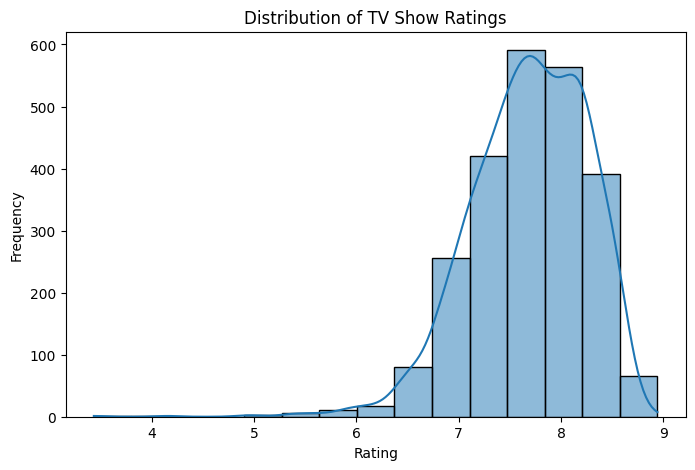

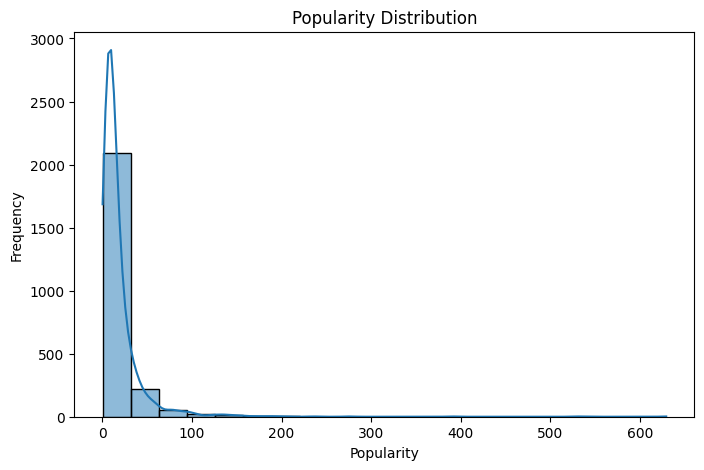

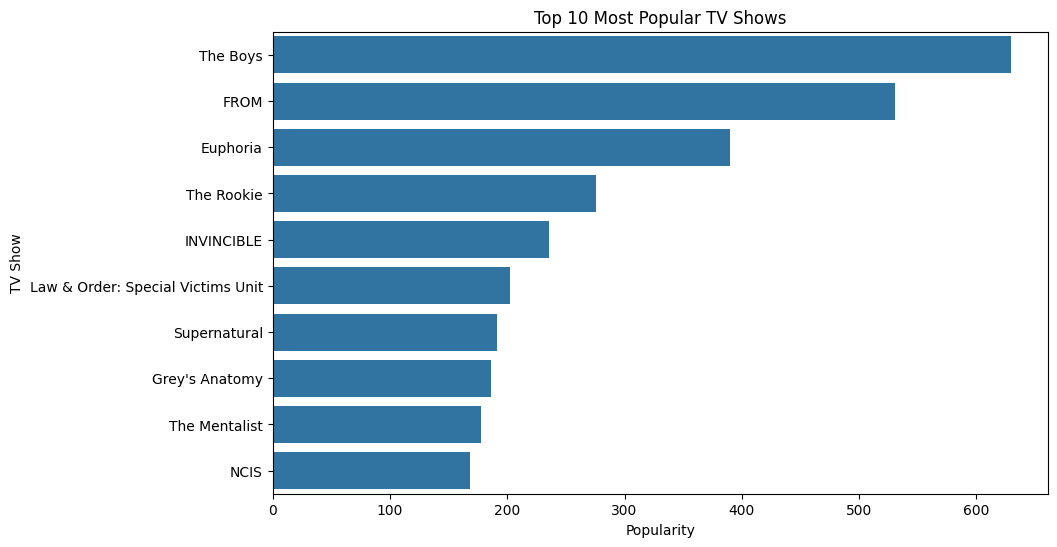

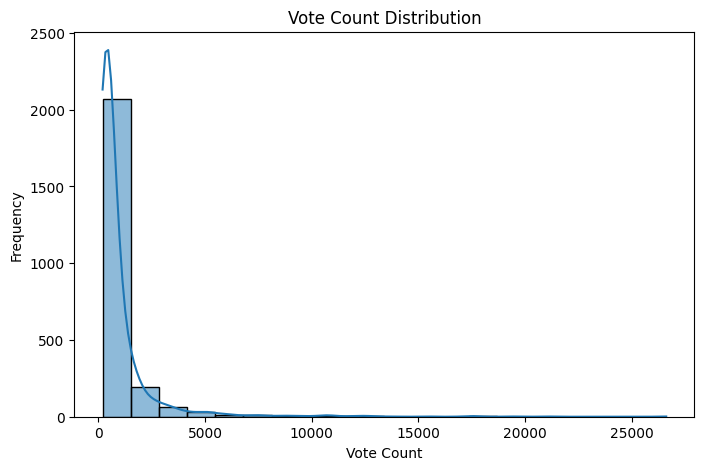

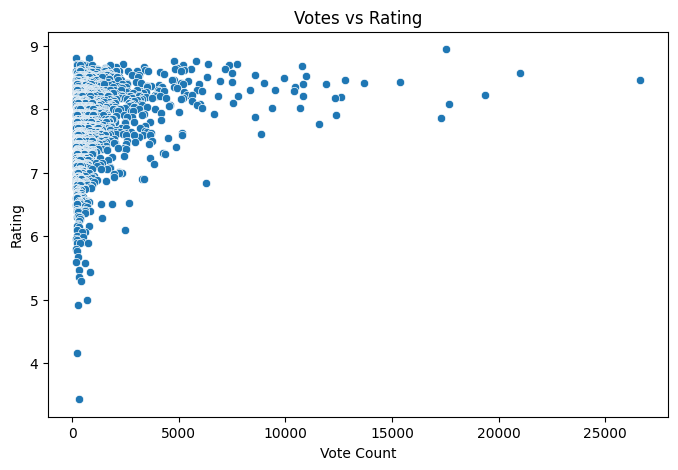


Final Conclusion:

1. The dataset mainly includes highly rated TV shows, leading to a skew toward higher ratings.
2. Popularity varies widely, with a few standout shows.
3. Audience engagement (vote count) differs significantly across shows.
4. There is no strong direct relationship between ratings and number of votes.
5. Data cleaning and preprocessing improved consistency for analysis.



In [6]:
# ==========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# Dataset: Top Rated TV Shows (TMDB)
# ==========================================

# ----------- Import Libraries -----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------- Upload File -----------
from google.colab import files
uploaded = files.upload()

# ----------- Load Dataset -----------
df = pd.read_csv("top_rated_tv.csv")

print("First 5 Rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


# ----------- Data Cleaning -----------

# Fill missing values
df.fillna(method='ffill', inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


# ----------- Data Preprocessing -----------

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("-", "_")

print("\nColumn Names:")
print(df.columns)


# ----------- Data Visualization -----------

# ⚠️ Adjust column names if needed using print(df.columns)

# 1. Rating Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['vote_average'], bins=15, kde=True)
plt.title("Distribution of TV Show Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# Observation:
# Most TV shows have ratings clustered in the higher range, indicating quality bias in top-rated data.


# 2. Popularity Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['popularity'], bins=20, kde=True)
plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.show()

# Observation:
# A few shows are extremely popular, while most fall in a moderate popularity range.


# 3. Top 10 Most Popular Shows
top10 = df.sort_values(by='popularity', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='popularity', y='name', data=top10)
plt.title("Top 10 Most Popular TV Shows")
plt.xlabel("Popularity")
plt.ylabel("TV Show")
plt.show()

# Observation:
# Certain TV shows dominate popularity rankings significantly.


# 4. Votes Count Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['vote_count'], bins=20, kde=True)
plt.title("Vote Count Distribution")
plt.xlabel("Vote Count")
plt.ylabel("Frequency")
plt.show()

# Observation:
# Most shows receive a moderate number of votes, with a few having very high engagement.


# ----------- Extra Graph (Optional Bonus) -----------

plt.figure(figsize=(8,5))
sns.scatterplot(x='vote_count', y='vote_average', data=df)
plt.title("Votes vs Rating")
plt.xlabel("Vote Count")
plt.ylabel("Rating")
plt.show()

# Observation:
# Higher vote counts do not always guarantee higher ratings.


# ----------- Final Conclusion -----------

print("""
Final Conclusion:

1. The dataset mainly includes highly rated TV shows, leading to a skew toward higher ratings.
2. Popularity varies widely, with a few standout shows.
3. Audience engagement (vote count) differs significantly across shows.
4. There is no strong direct relationship between ratings and number of votes.
5. Data cleaning and preprocessing improved consistency for analysis.
""")